# Energy Data Analysis

This notebook imports `energydata_complete.csv`, renames columns to descriptive names, inspects the data, and visualizes missing values using `missingno`.

In [20]:
# 1. Import libraries
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

%matplotlib inline

In [21]:
# 2. Load energy dataset into a pandas DataFrame
df = pd.read_csv('energydata_complete.csv')
print("Original shape:", df.shape)
df.head()

Original shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [22]:
# 3. Rename columns to descriptive names
column_mapping = {
    'date': 'datetime',
    'Appliances': 'appliances_energy_wh',
    'lights': 'lights_energy_wh',
    'T1': 'temp_kitchen_c',
    'RH_1': 'humidity_kitchen_pct',
    'T2': 'temp_living_room_c',
    'RH_2': 'humidity_living_room_pct',
    'T3': 'temp_laundry_c',
    'RH_3': 'humidity_laundry_pct',
    'T4': 'temp_office_c',
    'RH_4': 'humidity_office_pct',
    'T5': 'temp_bathroom_c',
    'RH_5': 'humidity_bathroom_pct',
    'T6': 'temp_outside_north_c',
    'RH_6': 'humidity_outside_north_pct',
    'T7': 'temp_ironing_room_c',
    'RH_7': 'humidity_ironing_room_pct',
    'T8': 'temp_teen_room_c',
    'RH_8': 'humidity_teen_room_pct',
    'T9': 'temp_parents_room_c',
    'RH_9': 'humidity_parents_room_pct',
    'T_out': 'temp_weather_station_c',
    'Press_mm_hg': 'pressure_weather_station_mmhg',
    'RH_out': 'humidity_weather_station_pct',
    'Windspeed': 'windspeed_weather_station_ms',
    'Visibility': 'visibility_weather_station_km',
    'Tdewpoint': 'dewpoint_weather_station_c',
    'rv1': 'random_variable_1',
    'rv2': 'random_variable_2'
}

df = df.rename(columns=column_mapping)
print("Columns renamed successfully!")
df.head()

Columns renamed successfully!


,datetime,appliances_energy_wh,lights_energy_wh,temp_kitchen_c,humidity_kitchen_pct,temp_living_room_c,humidity_living_room_pct,temp_laundry_c,humidity_laundry_pct,temp_office_c,...,temp_parents_room_c,humidity_parents_room_pct,temp_weather_station_c,pressure_weather_station_mmhg,humidity_weather_station_pct,windspeed_weather_station_ms,visibility_weather_station_km,dewpoint_weather_station_c,random_variable_1,random_variable_2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [23]:
# 4. Check dataset shape and view updated column list
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Renamed Columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2d}. {col}")

Shape: 19735 rows, 29 columns

Renamed Columns:
 1. datetime
 2. appliances_energy_wh
 3. lights_energy_wh
 4. temp_kitchen_c
 5. humidity_kitchen_pct
 6. temp_living_room_c
 7. humidity_living_room_pct
 8. temp_laundry_c
 9. humidity_laundry_pct
10. temp_office_c
11. humidity_office_pct
12. temp_bathroom_c
13. humidity_bathroom_pct
14. temp_outside_north_c
15. humidity_outside_north_pct
16. temp_ironing_room_c
17. humidity_ironing_room_pct
18. temp_teen_room_c
19. humidity_teen_room_pct
20. temp_parents_room_c
21. humidity_parents_room_pct
22. temp_weather_station_c
23. pressure_weather_station_mmhg
24. humidity_weather_station_pct
25. windspeed_weather_station_ms
26. visibility_weather_station_km
27. dewpoint_weather_station_c
28. random_variable_1
29. random_variable_2


In [24]:
# 5. Check null values per column
null_counts = df.isnull().sum()
print("Total null values across dataset:", null_counts.sum())
print("\nNull counts by column:")
print(null_counts)

Total null values across dataset: 0

Null counts by column:
datetime                         0
appliances_energy_wh             0
lights_energy_wh                 0
temp_kitchen_c                   0
humidity_kitchen_pct             0
temp_living_room_c               0
humidity_living_room_pct         0
temp_laundry_c                   0
humidity_laundry_pct             0
temp_office_c                    0
humidity_office_pct              0
temp_bathroom_c                  0
humidity_bathroom_pct            0
temp_outside_north_c             0
humidity_outside_north_pct       0
temp_ironing_room_c              0
humidity_ironing_room_pct        0
temp_teen_room_c                 0
humidity_teen_room_pct           0
temp_parents_room_c              0
humidity_parents_room_pct        0
temp_weather_station_c           0
pressure_weather_station_mmhg    0
humidity_weather_station_pct     0
windspeed_weather_station_ms     0
visibility_weather_station_km    0
dewpoint_weather_station_c    

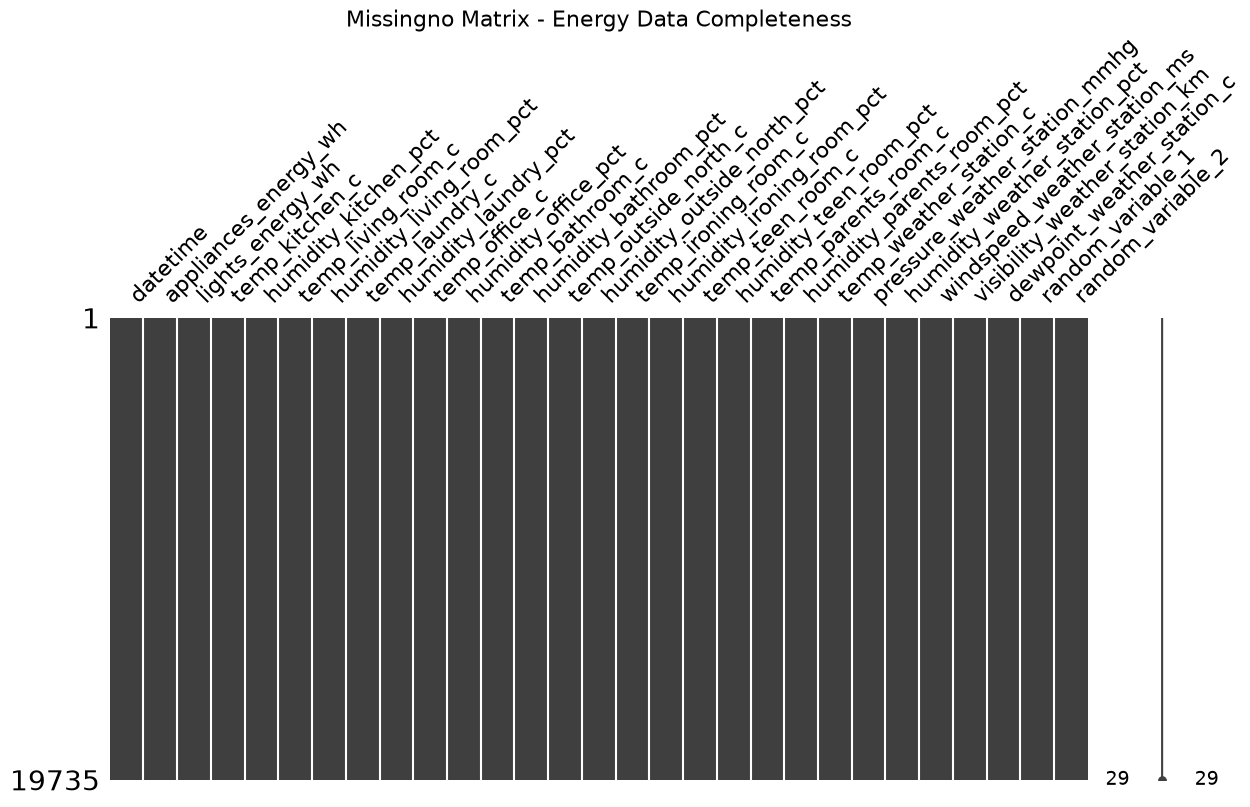

In [25]:
# 6. Visualizing missing values using missingno matrix
msno.matrix(df, figsize=(14, 6))
plt.title("Missingno Matrix - Energy Data Completeness", fontsize=16)
plt.show()

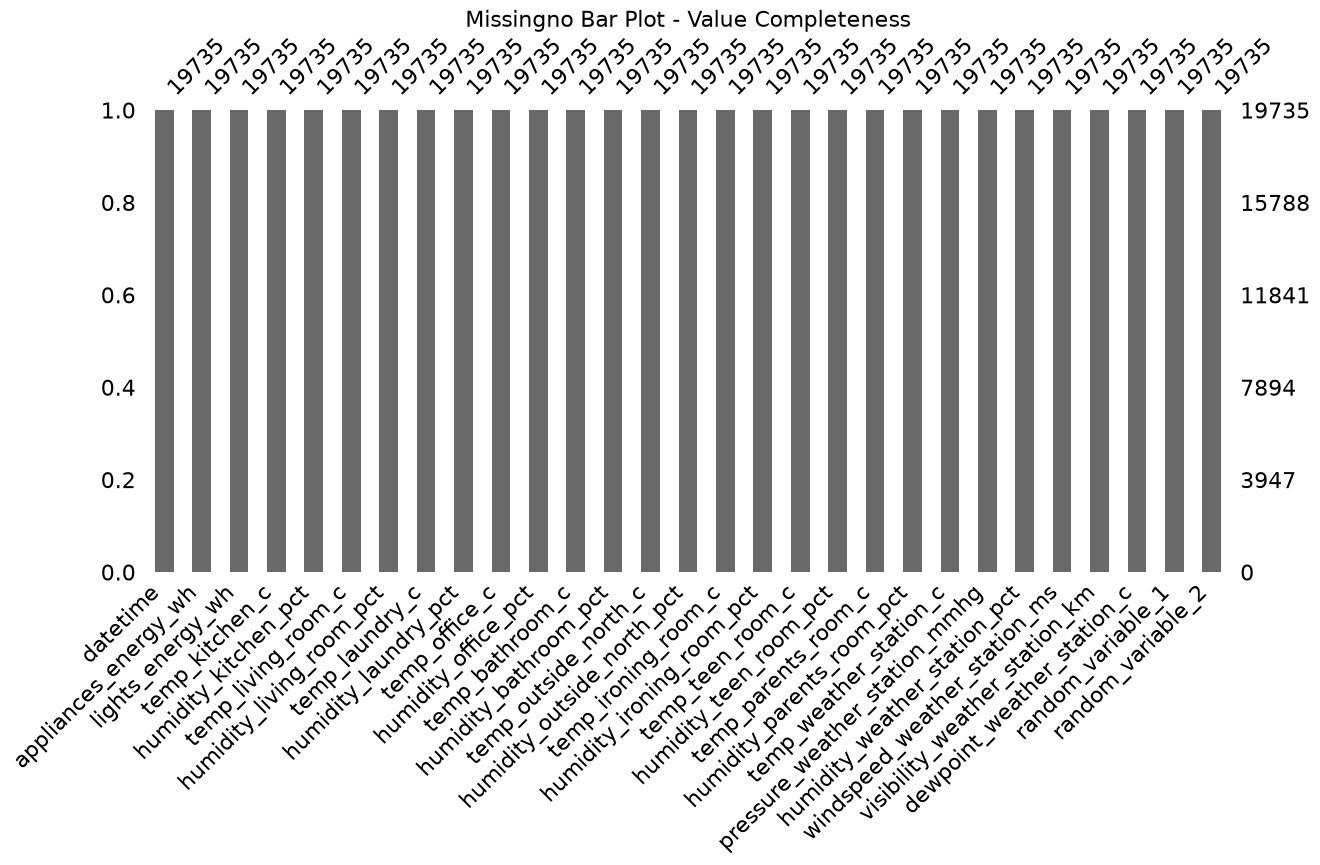

In [26]:
# 7. Visualizing missing values using missingno bar plot
msno.bar(df, figsize=(14, 6))
plt.title("Missingno Bar Plot - Value Completeness", fontsize=16)
plt.show()